<a href="https://colab.research.google.com/github/cristinalopez1163/03MIAR---Algoritmos-de-Optimizacion/blob/main/AG1/Algoritmos_Cristina_Lopez_AG1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Algoritmos - Actividad Guiada 1

Nombre: Cristina López Blanco<br>
URL: https://colab.research.google.com/drive/1rbaguSeCRLvb8UI-AHbqboKhSwzklhfr?authuser=1#scrollTo=kQn6fbhgtH9I<br>

https://github.com/cristinalopez1163/03MIAR---Algoritmos-de-Optimizacion.git<br>


## Elementos añadidos
- Torres de Hanoi: Añadir la ficha que se mueve en cada caso
- Cambio de monedas: Ejemplo en el que la técnica voraz no obtiene la solución óptima.
- Puntos más cercanos en una lista: Implementación por fuerza bruta y por divide y vencerás; cálculo de distancia y complejidad.

##Torres de Hanoi con Divide y vencerás

In [ ]:
def Torres_Hanoi(N, desde, hasta):
  # N - Nº de fichas
  # desde - torre inicial
  # hasta - torre final
  colores = {1: "Roja", 2: "Amarilla", 3: "Verde"}

  if N ==1 :
    print(f"Lleva la ficha {colores[N]} desde {desde} hasta {hasta}")

  else:
    # 6 - 1 - 3 = 6 - 4 = 2 // 6 - 2 - 3 = 6 - 5 = 1 // 6 - 1 - 2 = 6 - 3 = 3
    Torres_Hanoi(N-1, desde, 6-desde-hasta )
    print(f"Lleva la ficha {colores[N]} desde {desde} hasta {hasta}")
    Torres_Hanoi(N-1, 6-desde-hasta  , hasta )

Torres_Hanoi(3, 1 , 3)

# Roja
# Amarilla
# Verde

# Llamadas recursivas:
# -> Torres_Hanoi(2, 1, 2)
# -> -> Torres_Hanoi(1, 1, 3)
# -> -> -> Lleva la ficha Roja desde 1 hasta 3 ->  [Amarilla//Verde 0 Roja]
# -> -> -> Lleva la ficha Amarilla desde 1 hasta 2 ->  [Verde Amarilla Roja]
# -> -> Torres_Hanoi(1, 3, 2)
# -> -> -> Lleva la ficha Roja desde 3 hasta 2 ->  [Verde Roja//Amarilla 0]
# -> -> -> Lleva la ficha Verde desde 1 hasta 3 -> [0 Roja//Amarilla Verde]
# -> Torres_Hanoi(2, 2, 3)
# -> -> Torres_Hanoi(1, 2, 1)
# -> -> -> Lleva la ficha Roja desde 2 hasta 1 -> [Roja Amarilla Verde]
# -> -> -> Lleva la ficha Amarilla desde 2 hasta 3 -> [Roja 0 Amarilla//Verde]
# -> -> Torres_Hanoi(1, 1, 3)
# -> -> -> Lleva la ficha Roja desde 1 hasta 3 -> [0 0 Roja//Amarilla//Verde]


Lleva la ficha Roja desde 1 hasta 3
Lleva la ficha Amarilla desde 1 hasta 2
Lleva la ficha Roja desde 3 hasta 2
Lleva la ficha Verde desde 1 hasta 3
Lleva la ficha Roja desde 2 hasta 1
Lleva la ficha Amarilla desde 2 hasta 3
Lleva la ficha Roja desde 1 hasta 3


## Sucesión de Fibonacci

In [ ]:
#Sucesión_de_Fibonacci
#https://es.wikipedia.org/wiki/Sucesi%C3%B3n_de_Fibonacci
#Calculo del termino n-simo de la suscesión de Fibonacci
def Fibonacci(N:int):
  if N < 2:
    return 1
  else:
    return Fibonacci(N-1)+Fibonacci(N-2)

Fibonacci(5)

8

##Devolución de cambio por técnica voraz

In [ ]:
def cambio_monedas(N, SM):
  SOLUCION = [0]*len(SM)   # Inicializamos el array que contendrá la cantidad de monedas de cada valor. SOLUCION = [0,0,0,0,..]
  ValorAcumulado = 0       # Inicializamos el valor acumulado

  for i,valor in enumerate(SM):                     # Recorremos el sistema monetario
    monedas =  (N-ValorAcumulado)//valor            # Calcula la candidad de monedas de valor SISTEMA[i] (Función de selección)
    SOLUCION[i] = monedas                           # Añade el número de monedas a la solución
    ValorAcumulado = ValorAcumulado + monedas*valor # Incrementa el valor acumulado (Función de factibilidad)

    if ValorAcumulado == N:                         # Finalizamos si ya hemos llegado a la solución (Criterio de solución final)
      return SOLUCION


cambio_monedas(15,[25,10,5,1])

[0, 1, 1, 0]

Este algoritmo voraz no siempre produce la solución óptima. Existen sistemas monetarios para los cuales la estrategia greedy falla.

In [ ]:
cambio_monedas(24, [20, 12, 6, 2, 1])

[1, 0, 0, 2, 0]

En este ejemplo, el algoritmo selecciona primero una moneda de 20 y, posteriormente, dos monedas de 2, obteniendo un total de 3 monedas para alcanzar el valor 24. Sin embargo, esta no es la mejor solución posible, ya que una solución óptima sería utilizar únicamente dos monedas de 12.

## N-Reinas por técnica de vueta atrás


In [ ]:
def escribe(S):
  n = len(S)
  for x in range(n):
    print("")
    for i in range(n):
      if S[i] == x+1:
        print(" X " , end="")
      else:
        print(" - ", end="")


def es_prometedora(SOLUCION,etapa):
  # print(SOLUCION)
  # Si la solución tiene dos valores iguales no es valida => Dos reinas en la misma fila
  for i in range(etapa+1):
    #print("El valor " + str(SOLUCION[i]) + " está " +  str(SOLUCION.count(SOLUCION[i])) + " veces")
    if SOLUCION.count(SOLUCION[i]) > 1:
      return False

    #Verifica las diagonales
    for j in range(i+1, etapa +1 ):
      #print("Comprobando diagonal de " + str(i) + " y " + str(j))
      if abs(i-j) == abs(SOLUCION[i]-SOLUCION[j]) : return False
  return True



def reinas(N, solucion=[], etapa=0):
  if len(solucion) == 0:
      solucion=[0 for i in range(N)]

  for i in range(1, N+1):
    solucion[etapa] = i

    if es_prometedora(solucion, etapa):
      if etapa == N-1:
        print(solucion)
        #escribe(solucion)
        print()
      else:
        reinas(N, solucion, etapa+1)
    else:
      None

    solucion[etapa] = 0

reinas(8)

[1, 5, 8, 6, 3, 7, 2, 4]

[1, 6, 8, 3, 7, 4, 2, 5]

[1, 7, 4, 6, 8, 2, 5, 3]

[1, 7, 5, 8, 2, 4, 6, 3]

[2, 4, 6, 8, 3, 1, 7, 5]

[2, 5, 7, 1, 3, 8, 6, 4]

[2, 5, 7, 4, 1, 8, 6, 3]

[2, 6, 1, 7, 4, 8, 3, 5]

[2, 6, 8, 3, 1, 4, 7, 5]

[2, 7, 3, 6, 8, 5, 1, 4]

[2, 7, 5, 8, 1, 4, 6, 3]

[2, 8, 6, 1, 3, 5, 7, 4]

[3, 1, 7, 5, 8, 2, 4, 6]

[3, 5, 2, 8, 1, 7, 4, 6]

[3, 5, 2, 8, 6, 4, 7, 1]

[3, 5, 7, 1, 4, 2, 8, 6]

[3, 5, 8, 4, 1, 7, 2, 6]

[3, 6, 2, 5, 8, 1, 7, 4]

[3, 6, 2, 7, 1, 4, 8, 5]

[3, 6, 2, 7, 5, 1, 8, 4]

[3, 6, 4, 1, 8, 5, 7, 2]

[3, 6, 4, 2, 8, 5, 7, 1]

[3, 6, 8, 1, 4, 7, 5, 2]

[3, 6, 8, 1, 5, 7, 2, 4]

[3, 6, 8, 2, 4, 1, 7, 5]

[3, 7, 2, 8, 5, 1, 4, 6]

[3, 7, 2, 8, 6, 4, 1, 5]

[3, 8, 4, 7, 1, 6, 2, 5]

[4, 1, 5, 8, 2, 7, 3, 6]

[4, 1, 5, 8, 6, 3, 7, 2]

[4, 2, 5, 8, 6, 1, 3, 7]

[4, 2, 7, 3, 6, 8, 1, 5]

[4, 2, 7, 3, 6, 8, 5, 1]

[4, 2, 7, 5, 1, 8, 6, 3]

[4, 2, 8, 5, 7, 1, 3, 6]

[4, 2, 8, 6, 1, 3, 5, 7]

[4, 6, 1, 5, 2, 8, 3, 7]

[4, 6, 8, 2, 7, 1, 3, 5]

[4, 6, 8, 3,

## Viaje por el rio. Programación dinámica

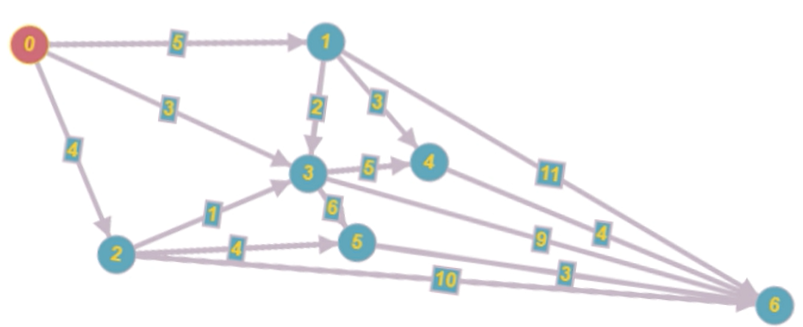

In [ ]:
TARIFAS = [
[0,5,4,3,999,999,999],
[999,0,999,2,3,999,11],
[999,999, 0,1,999,4,10],
[999,999,999, 0,5,6,9],
[999,999, 999,999,0,999,4],
[999,999, 999,999,999,0,3],
[999,999,999,999,999,999,0]
]



################################################################
def Precios(TARIFAS):
################################################################
  #Total de Nodos
  N = len(TARIFAS[0])

  #Inicialización de la tabla de precios
  PRECIOS = [ [9999]*N for i in [9999]*N]
  RUTA = [ [""]*N for i in [""]*N]

  for i in range(0,N-1):
    RUTA[i][i] = i             #Para ir de i a i se "pasa por i"
    PRECIOS[i][i] = 0          #Para ir de i a i se se paga 0
    for j in range(i+1, N):
      MIN = TARIFAS[i][j]
      RUTA[i][j] = i

      for k in range(i, j):
        if PRECIOS[i][k] + TARIFAS[k][j] < MIN:
            MIN = min(MIN, PRECIOS[i][k] + TARIFAS[k][j] )
            RUTA[i][j] = k      # Para ir de i a j hay que pasar por k
        PRECIOS[i][j] = MIN

  return PRECIOS,RUTA
################################################################


PRECIOS,RUTA = Precios(TARIFAS)
#print(PRECIOS[0][6])

print("PRECIOS")
for i in range(len(TARIFAS)):
  print(PRECIOS[i])

print("\nRUTA")
for i in range(len(TARIFAS)):
  print(RUTA[i])

#Determinar la ruta con Recursividad
def calcular_ruta(RUTA, desde, hasta):
  if desde == hasta:
    #print("Ir a :" + str(desde))
    return ""
  else:
    return str(calcular_ruta( RUTA, desde, RUTA[desde][hasta])) +  \
                ',' + \
                str(RUTA[desde][hasta] \
              )

print("\nLa ruta es:")
calcular_ruta(RUTA, 0,6)

PRECIOS
[0, 5, 4, 3, 8, 8, 11]
[9999, 0, 999, 2, 3, 8, 7]
[9999, 9999, 0, 1, 6, 4, 7]
[9999, 9999, 9999, 0, 5, 6, 9]
[9999, 9999, 9999, 9999, 0, 999, 4]
[9999, 9999, 9999, 9999, 9999, 0, 3]
[9999, 9999, 9999, 9999, 9999, 9999, 9999]

RUTA
[0, 0, 0, 0, 1, 2, 5]
['', 1, 1, 1, 1, 3, 4]
['', '', 2, 2, 3, 2, 5]
['', '', '', 3, 3, 3, 3]
['', '', '', '', 4, 4, 4]
['', '', '', '', '', 5, 5]
['', '', '', '', '', '', '']

La ruta es:


',0,2,5'

## Encontrar los dos puntos más cercanos

### Fuerza bruta

In [ ]:
import random

def puntos_cercanos_fuerza_bruta(lista):
  puntos = ()                              # Asignación: 1 operación básica
  distancia_min = float('inf')             # Asignación: 1 operación básica
  for i in range(len(lista)):              # Bucle: n iteraciones
    for j in range(i + 1, len(lista)):     # Bucle interno: n-1 iteraciones
      distancia = abs(lista[i] - lista[j]) # Distancia: K operaciones
      if distancia < distancia_min:        # Comparación: 1 operación
        distancia_min = distancia          # Asignación: 1 operación
        puntos = (lista[i], lista[j])      # Asignación: 1 operación
  return puntos, distancia_min             # Return: 1 operación

LISTA_1D = [random.randrange(1, 10000000) for x in range(1, 1000)]
puntos, distancia = puntos_cercanos_fuerza_bruta(LISTA_1D)
print(f"Los puntos más próximos son {puntos} y se encuentran a una distancia de {distancia}.")

Los puntos más próximos son (7133439, 7133435) y se encuentran a una distancia de 4.


Total de operaciones: $K \cdot n^2 + 4$

Complejidad: $O(n^2)$

### Divide y vencerás

In [ ]:
def puntos_cercanos_dyv(lista):
    # Ordenamos solo una vez
    lista_ordenada = sorted(lista)               # Coste -> O(n log n)
    return puntos_cercanos_rec(lista_ordenada)

def puntos_cercanos_rec(lista):
    n = len(lista)                               # Coste -> O(1)

    # Casos base
    if n == 1:
        return (None, None), float('inf')   # No existe pareja, distancia infinita


    # Coste -> O(1)
    if n == 2:
        return (lista[0], lista[1]), abs(lista[1] - lista[0])

    # Dividimos la lista en dos mitades
    mediana = n // 2
    S1 = lista[:mediana]
    S2 = lista[mediana:]

    # Resolvemos cada mitad recursivamente
    # Genera dos subproblemas de tamaño n / 2
    (p1_1, p2_1), d1 = puntos_cercanos_rec(S1)
    (p1_2, p2_2), d2 = puntos_cercanos_rec(S2)

    # distancia entre el punto máximo de S1 y el mínimo de S2 (frontera)
    # Coste -> O(1)
    d12 = abs(S2[0] - S1[-1])
    p12 = (S1[-1], S2[0])

    # Elegimos el mínimo
    # Coste -> O(1)
    if d1 <= d2 and d1 <= d12:
        return (p1_1, p2_1), d1
    elif d2 <= d1 and d2 <= d12:
        return (p1_2, p2_2), d2
    else:
        return p12, d12


puntos, distancia = puntos_cercanos_dyv(LISTA_1D)
print(f"Los puntos más próximos son {puntos} y se encuentran a una distancia de {distancia}.")

Los puntos más próximos son (7133435, 7133439) y se encuentran a una distancia de 4.


- Ordenar la lista: $O(n \cdot log (n))$
- Divide y vencerás: Genera dos subproblemas de tamaño $n / 2$ y realiza trabajo adicional constante. Por tanto su recurrencia es $T(n) = 2T(n/2) + O(1)$. Esto da $O(n)$

Complejidad total: $O(n \cdot log (n) + n) = O(n \cdot log (n))$


La complejidad del algoritmo divide y vencerás ha disminuido con respecto al de fuerza bruta.